In [ ]:
# RECOVERY + STEP B1: locate/download dataset, then build PACFNet-style beat dataset

!pip -q install kaggle wfdb biosppy peakutils scipy numpy pandas tqdm

import os
import numpy as np
import pandas as pd
import wfdb
from scipy import signal
from biosppy.signals import ecg
from tqdm.auto import tqdm
from pathlib import Path

# --------------------------------------------------
# 1) locate dataset or download if missing
# --------------------------------------------------
candidates = [
    Path("/content/physionet2016/training-a"),
    Path("/content/physionet2016"),
    Path("/kaggle/input/physionet-challenge-2016"),
]

data_root = None
for c in candidates:
    if c.exists():
        data_root = c
        break

if data_root is None:
    print("Dataset not found in runtime. Downloading...")
    os.makedirs("/content/physionet2016", exist_ok=True)

    # This expects kaggle.json already set up in the runtime.
    # If this fails, re-upload kaggle.json first.
    os.system("mkdir -p /root/.kaggle")
    os.system("chmod 600 /root/.kaggle/kaggle.json 2>/dev/null")

    ret = os.system("kaggle datasets download -d bjoernjostein/physionet-challenge-2016 -p /content/physionet2016 --unzip")
    print("Download return code:", ret)

    if Path("/content/physionet2016/training-a").exists():
        data_root = Path("/content/physionet2016/training-a")
    elif Path("/content/physionet2016").exists():
        data_root = Path("/content/physionet2016")
else:
    print("Found existing dataset root:", data_root)

# normalize to training-a path
if data_root is not None and data_root.name != "training-a":
    ta = data_root / "training-a"
    if ta.exists():
        data_root = ta

print("Using DATA_ROOT:", data_root)

if data_root is None or not data_root.exists():
    raise FileNotFoundError("Could not find or download training-a. If needed, upload kaggle.json and rerun.")

# --------------------------------------------------
# 2) build labels from .hea comments
# --------------------------------------------------
def infer_label_from_header(hea_path):
    lines = open(hea_path, "r", errors="ignore").read().splitlines()
    label = None
    for line in lines:
        s = line.strip().lower()
        if not s.startswith("#"):
            continue
        if "abnormal" in s:
            label = 1
        elif "normal" in s and "abnormal" not in s:
            label = 0
    return label

records = sorted([f[:-4] for f in os.listdir(data_root) if f.endswith(".hea")])

label_dict = {}
for rid in records:
    lab = infer_label_from_header(data_root / f"{rid}.hea")
    if lab is not None:
        label_dict[rid] = lab

print("Total labels from headers:", len(label_dict))
print(pd.Series(list(label_dict.values())).value_counts().sort_index())

# --------------------------------------------------
# 3) helpers
# --------------------------------------------------
def load_record(record_base, target_fs=2000):
    rec = wfdb.rdrecord(record_base)
    fs = int(rec.fs)

    # confirmed in this mirror:
    # channel 0 = PCG, channel 1 = ECG
    pcg_raw = rec.p_signal[:, 0].astype(np.float64)
    ecg_raw = rec.p_signal[:, 1].astype(np.float64)

    if fs != target_fs:
        n = int(len(ecg_raw) * target_fs / fs)
        ecg_raw = signal.resample(ecg_raw, n)
        pcg_raw = signal.resample(pcg_raw, n)
        fs = target_fs

    return ecg_raw, pcg_raw, fs

def apply_filters(ecg_sig, pcg_sig, fs):
    sos_ecg = signal.butter(4, [0.5, 20], btype="bandpass", fs=fs, output="sos")
    ecg_f = signal.sosfiltfilt(sos_ecg, ecg_sig)

    sos_pcg = signal.butter(4, [25, 400], btype="bandpass", fs=fs, output="sos")
    pcg_f = signal.sosfiltfilt(sos_pcg, pcg_sig)

    ecg_f = (ecg_f - np.mean(ecg_f)) / (np.std(ecg_f) + 1e-8)
    pcg_f = (pcg_f - np.mean(pcg_f)) / (np.std(pcg_f) + 1e-8)

    return ecg_f.astype(np.float32), pcg_f.astype(np.float32)

def segment_beats(ecg_sig, pcg_sig, fs):
    try:
        out = ecg.christov_segmenter(signal=ecg_sig, sampling_rate=fs)
        r_peaks = np.asarray(out["rpeaks"], dtype=int)
    except Exception:
        return np.empty((0, 1600), dtype=np.float32), np.empty((0, 1600), dtype=np.float32)

    ecg_beats, pcg_beats = [], []
    before = int(0.3 * fs)   # 600
    after  = int(0.5 * fs)   # 1000

    for r in r_peaks:
        if r - before > 0 and r + after < len(ecg_sig):
            e = ecg_sig[r-before:r+after]
            p = pcg_sig[r-before:r+after]
            if len(e) == 1600 and len(p) == 1600:
                ecg_beats.append(e)
                pcg_beats.append(p)

    if len(ecg_beats) == 0:
        return np.empty((0, 1600), dtype=np.float32), np.empty((0, 1600), dtype=np.float32)

    return np.asarray(ecg_beats, dtype=np.float32), np.asarray(pcg_beats, dtype=np.float32)

# --------------------------------------------------
# 4) build beat dataset
# --------------------------------------------------
all_ecg = []
all_pcg = []
all_y = []
all_record_ids = []

used_records = 0
failed_records = 0

for rid in tqdm(records):
    if rid not in label_dict:
        continue
    try:
        ecg_raw, pcg_raw, fs = load_record(str(data_root / rid), target_fs=2000)
        ecg_f, pcg_f = apply_filters(ecg_raw, pcg_raw, fs)
        e_beats, p_beats = segment_beats(ecg_f, pcg_f, fs)

        if len(e_beats) == 0:
            failed_records += 1
            continue

        y = label_dict[rid]
        all_ecg.append(e_beats[..., None])
        all_pcg.append(p_beats[..., None])
        all_y.append(np.full((len(e_beats),), y, dtype=np.int64))
        all_record_ids.extend([rid] * len(e_beats))
        used_records += 1
    except Exception:
        failed_records += 1
        continue

X_ecg = np.concatenate(all_ecg, axis=0)
X_pcg = np.concatenate(all_pcg, axis=0)
y = np.concatenate(all_y, axis=0)
record_ids = np.array(all_record_ids)

print("X_ecg:", X_ecg.shape)
print("X_pcg:", X_pcg.shape)
print("y:", y.shape)
print("Class counts:", np.bincount(y))
print("Unique records used:", len(np.unique(record_ids)))
print("Used records:", used_records)
print("Failed/no-beat records:", failed_records)

np.savez_compressed(
    "/content/pacfnet_beat_dataset.npz",
    X_ecg=X_ecg,
    X_pcg=X_pcg,
    y=y,
    record_ids=record_ids
)

print("Saved: /content/pacfnet_beat_dataset.npz")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 55.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<

  0%|          | 0/409 [00:00<?, ?it/s]

X_ecg: (6975, 1600, 1)
X_pcg: (6975, 1600, 1)
y: (6975,)
Class counts: [2699 4276]
Unique records used: 186
Used records: 186
Failed/no-beat records: 223
Saved: /content/pacfnet_beat_dataset.npz


In [ ]:
# STEP B3: sanitize PACFNet beat dataset and inspect NaNs / ranges

import numpy as np

data = np.load("/content/pacfnet_beat_dataset.npz", allow_pickle=True)
X_ecg = data["X_ecg"].astype(np.float32)
X_pcg = data["X_pcg"].astype(np.float32)
y = data["y"].astype(np.int64)
record_ids = data["record_ids"]

print("Original shapes:")
print("X_ecg:", X_ecg.shape)
print("X_pcg:", X_pcg.shape)
print("y:", y.shape)

print("\n=== RAW FINITE CHECK ===")
print("ECG NaNs:", np.isnan(X_ecg).sum())
print("ECG infs:", np.isinf(X_ecg).sum())
print("PCG NaNs:", np.isnan(X_pcg).sum())
print("PCG infs:", np.isinf(X_pcg).sum())

print("\n=== RAW RANGE CHECK ===")
print("ECG abs max:", float(np.nanmax(np.abs(X_ecg))))
print("PCG abs max:", float(np.nanmax(np.abs(X_pcg))))
print("ECG mean/std:", float(np.nanmean(X_ecg)), float(np.nanstd(X_ecg)))
print("PCG mean/std:", float(np.nanmean(X_pcg)), float(np.nanstd(X_pcg)))

# per-beat validity
ecg_ok = np.isfinite(X_ecg).all(axis=(1,2))
pcg_ok = np.isfinite(X_pcg).all(axis=(1,2))

# variance check
ecg_var_ok = X_ecg.std(axis=(1,2)) > 1e-6
pcg_var_ok = X_pcg.std(axis=(1,2)) > 1e-6

valid = ecg_ok & pcg_ok & ecg_var_ok & pcg_var_ok

print("\nValid beats:", int(valid.sum()))
print("Dropped beats:", int((~valid).sum()))

X_ecg_clean = X_ecg[valid]
X_pcg_clean = X_pcg[valid]
y_clean = y[valid]
record_ids_clean = record_ids[valid]

# replace any remaining weird values just in case
X_ecg_clean = np.nan_to_num(X_ecg_clean, nan=0.0, posinf=0.0, neginf=0.0)
X_pcg_clean = np.nan_to_num(X_pcg_clean, nan=0.0, posinf=0.0, neginf=0.0)

# clip extremes
X_ecg_clean = np.clip(X_ecg_clean, -10.0, 10.0)
X_pcg_clean = np.clip(X_pcg_clean, -10.0, 10.0)

print("\n=== CLEAN RANGE CHECK ===")
print("X_ecg_clean:", X_ecg_clean.shape)
print("X_pcg_clean:", X_pcg_clean.shape)
print("Class counts:", np.bincount(y_clean))
print("Unique records:", len(np.unique(record_ids_clean)))
print("ECG abs max:", float(np.max(np.abs(X_ecg_clean))))
print("PCG abs max:", float(np.max(np.abs(X_pcg_clean))))
print("ECG mean/std:", float(np.mean(X_ecg_clean)), float(np.std(X_ecg_clean)))
print("PCG mean/std:", float(np.mean(X_pcg_clean)), float(np.std(X_pcg_clean)))

np.savez_compressed(
    "/content/pacfnet_beat_dataset_clean.npz",
    X_ecg=X_ecg_clean,
    X_pcg=X_pcg_clean,
    y=y_clean,
    record_ids=record_ids_clean
)

print("\nSaved: /content/pacfnet_beat_dataset_clean.npz")

Original shapes:
X_ecg: (6975, 1600, 1)
X_pcg: (6975, 1600, 1)
y: (6975,)

=== RAW FINITE CHECK ===
ECG NaNs: 0
ECG infs: 0
PCG NaNs: 582400
PCG infs: 0

=== RAW RANGE CHECK ===
ECG abs max: 14.89326286315918
PCG abs max: 39.07524108886719
ECG mean/std: 0.02066148817539215 1.0023999214172363
PCG mean/std: -9.898787538986653e-06 1.0326217412948608

Valid beats: 6611
Dropped beats: 364

=== CLEAN RANGE CHECK ===
X_ecg_clean: (6611, 1600, 1)
X_pcg_clean: (6611, 1600, 1)
Class counts: [2413 4198]
Unique records: 175
ECG abs max: 10.0
PCG abs max: 10.0
ECG mean/std: 0.019838474690914154 1.0040333271026611
PCG mean/std: -6.434162787627429e-05 1.0276483297348022

Saved: /content/pacfnet_beat_dataset_clean.npz


In [ ]:
# STEP B4: Stable PACFNet-style training on the cleaned beat dataset

!pip -q install tensorflow scikit-learn numpy pandas

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# -----------------------------
# Load cleaned beat dataset
# -----------------------------
data = np.load("/content/pacfnet_beat_dataset_clean.npz", allow_pickle=True)
X_ecg = data["X_ecg"].astype(np.float32)
X_pcg = data["X_pcg"].astype(np.float32)
y = data["y"].astype(np.int64)
record_ids = data["record_ids"]

print("Loaded clean dataset:")
print("X_ecg:", X_ecg.shape)
print("X_pcg:", X_pcg.shape)
print("y:", y.shape)
print("Class counts:", np.bincount(y))

# final safety clipping
X_ecg = np.clip(X_ecg, -8.0, 8.0)
X_pcg = np.clip(X_pcg, -8.0, 8.0)

# -----------------------------
# Beat-level split
# -----------------------------
X_e_train, X_e_test, X_p_train, X_p_test, y_train, y_test = train_test_split(
    X_ecg, X_pcg, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTrain beats:", len(y_train))
print("Test beats:", len(y_test))
print("Train class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))

# -----------------------------
# Balance training set
# -----------------------------
idx0 = np.where(y_train == 0)[0]
idx1 = np.where(y_train == 1)[0]

if len(idx0) < len(idx1):
    idx0_up = resample(idx0, replace=True, n_samples=len(idx1), random_state=42)
    idx_bal = np.concatenate([idx0_up, idx1])
else:
    idx1_up = resample(idx1, replace=True, n_samples=len(idx0), random_state=42)
    idx_bal = np.concatenate([idx0, idx1_up])

rng = np.random.default_rng(42)
rng.shuffle(idx_bal)

X_e_bal = X_e_train[idx_bal]
X_p_bal = X_p_train[idx_bal]
y_bal = y_train[idx_bal]

print("\nBalanced train counts:", np.bincount(y_bal))

# -----------------------------
# Milder augmentation
# -----------------------------
def augment_pair_batch(xe, xp, noise_std=0.005, max_shift=20):
    xe = xe.copy()
    xp = xp.copy()

    for i in range(len(xe)):
        shift = np.random.randint(-max_shift, max_shift + 1)
        xe[i, :, 0] = np.roll(xe[i, :, 0], shift)
        xp[i, :, 0] = np.roll(xp[i, :, 0], shift)

        xe[i, :, 0] += np.random.normal(0, noise_std, size=xe.shape[1])
        xp[i, :, 0] += np.random.normal(0, noise_std, size=xp.shape[1])

    xe = np.clip(xe, -8.0, 8.0)
    xp = np.clip(xp, -8.0, 8.0)
    return xe, xp

X_e_aug, X_p_aug = augment_pair_batch(X_e_bal, X_p_bal, noise_std=0.005, max_shift=20)

X_e_final = np.concatenate([X_e_bal, X_e_aug], axis=0)
X_p_final = np.concatenate([X_p_bal, X_p_aug], axis=0)
y_final = np.concatenate([y_bal, y_bal], axis=0)

print("Final train shape:", X_e_final.shape, X_p_final.shape, y_final.shape)
print("Final class counts:", np.bincount(y_final))

# -----------------------------
# Stable PACFNet-style model
# -----------------------------
def conv_branch(inp, base=48, name_prefix="x"):
    x = layers.Conv1D(base, 15, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(4)(x)

    x = layers.Conv1D(base * 2, 7, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Conv1D(base * 4, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x_avg = layers.GlobalAveragePooling1D()(x)
    x_max = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([x_avg, x_max])
    return x

def build_stable_pacfnet(input_shape=(1600, 1)):
    in_e = layers.Input(shape=input_shape, name="ECG_Input")
    in_p = layers.Input(shape=input_shape, name="PCG_Input")

    e = conv_branch(in_e, base=40, name_prefix="ecg")
    p = conv_branch(in_p, base=56, name_prefix="pcg")

    fused = layers.Concatenate()([e, p])

    x = layers.Dense(192, activation="relu")(fused)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(96, activation="relu")(x)
    x = layers.Dropout(0.20)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs=[in_e, in_p], outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model

tf.keras.utils.set_random_seed(42)
model = build_stable_pacfnet()
model.summary()

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

history = model.fit(
    [X_e_final, X_p_final],
    y_final,
    validation_data=([X_e_test, X_p_test], y_test),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# -----------------------------
# Final evaluation
# -----------------------------
y_prob = model.predict([X_e_test, X_p_test], batch_size=64).ravel()

# finite guard
y_prob = np.nan_to_num(y_prob, nan=0.5, posinf=1.0, neginf=0.0)
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("\n=== FINAL CLEAN BEAT-LEVEL RESULTS ===")
print("Accuracy:", acc)
print("F1:", f1)
print("AUC:", auc)
print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Abnormal"], zero_division=0))

Loaded clean dataset:
X_ecg: (6611, 1600, 1)
X_pcg: (6611, 1600, 1)
y: (6611,)
Class counts: [2413 4198]

Train beats: 5288
Test beats: 1323
Train class counts: [1930 3358]
Test class counts: [483 840]

Balanced train counts: [3358 3358]
Final train shape: (13432, 1600, 1) (13432, 1600, 1) (13432,)
Final class counts: [6716 6716]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ECG_Input           │ (None, 1600, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PCG_Input           │ (None, 1600, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1600, 40)  │        640 │ ECG_Input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1600, 56)  │        896 │ PCG_Input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1600, 40)  │        160 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1600, 56)  │        224 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 400, 40)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 400, 56)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 400, 80)   │     22,480 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 400, 112)  │     44,016 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 80)   │        320 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 112)  │        448 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 400, 80)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 400, 112)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 400, 160)  │     38,560 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 400, 224)  │     75,488 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 160)  │        640 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 224)  │        896 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 160)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 351,041 (1.34 MB)

 Trainable params: 349,697 (1.33 MB)

 Non-trainable params: 1,344 (5.25 KB)

Epoch 1/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.5851 - auc: 0.6140 - loss: 0.9660 - precision: 0.5857 - recall: 0.5814 - val_accuracy: 0.7294 - val_auc: 0.7714 - val_loss: 0.5695 - val_precision: 0.7081 - val_recall: 0.9762 - learning_rate: 5.0000e-05
Epoch 2/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.6947 - auc: 0.7683 - loss: 0.5759 - precision: 0.6891 - recall: 0.7094 - val_accuracy: 0.7166 - val_auc: 0.8605 - val_loss: 0.5306 - val_precision: 0.8805 - val_recall: 0.6405 - learning_rate: 5.0000e-05
Epoch 3/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7545 - auc: 0.8375 - loss: 0.4933 - precision: 0.7471 - recall: 0.7695 - val_accuracy: 0.7906 - val_auc: 0.9014 - val_loss: 0.4386 - val_precision: 0.9016 - val_recall: 0.7524 - learning_rate: 5.0000e-05
Epoch 4/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7921 - auc: 0.8760 - loss: 0.4389 - precision: 0.7831 - recall: 0.8081 - val_accuracy: 0.8292 - val_auc: 0.9308 - val_l

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd

# Final predictions
y_prob = model.predict([X_e_test, X_p_test], batch_size=64).ravel()
y_prob = np.nan_to_num(y_prob, nan=0.5, posinf=1.0, neginf=0.0)
y_pred = (y_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)   # sensitivity
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
spec = tn / (tn + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)
fpr = fp / (fp + tn + 1e-8)
fnr = fn / (fn + tp + 1e-8)
bal_acc = balanced_accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

results_df = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall / Sensitivity", "Specificity",
        "F1-score", "ROC-AUC", "Balanced Accuracy", "NPV",
        "False Positive Rate", "False Negative Rate", "MCC", "Cohen Kappa"
    ],
    "Value": [
        acc, prec, rec, spec,
        f1, auc, bal_acc, npv,
        fpr, fnr, mcc, kappa
    ]
})

print("Confusion Matrix:")
print(cm)
display(results_df)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Confusion Matrix:
[[476   7]
 [ 21 819]]


,Metric,Value
0,Accuracy,0.978836
1,Precision,0.991525
2,Recall / Sensitivity,0.975000
3,Specificity,0.985507
4,F1-score,0.983193
5,ROC-AUC,0.997836
6,Balanced Accuracy,0.980254
7,NPV,0.957746
8,False Positive Rate,0.014493
9,False Negative Rate,0.025000


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test, y_pred,
    target_names=["Normal", "Abnormal"],
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

      Normal     0.9577    0.9855    0.9714       483
    Abnormal     0.9915    0.9750    0.9832       840

    accuracy                         0.9788      1323
   macro avg     0.9746    0.9803    0.9773      1323
weighted avg     0.9792    0.9788    0.9789      1323



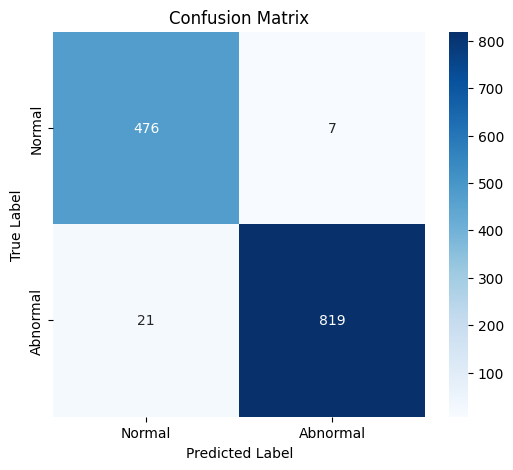

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

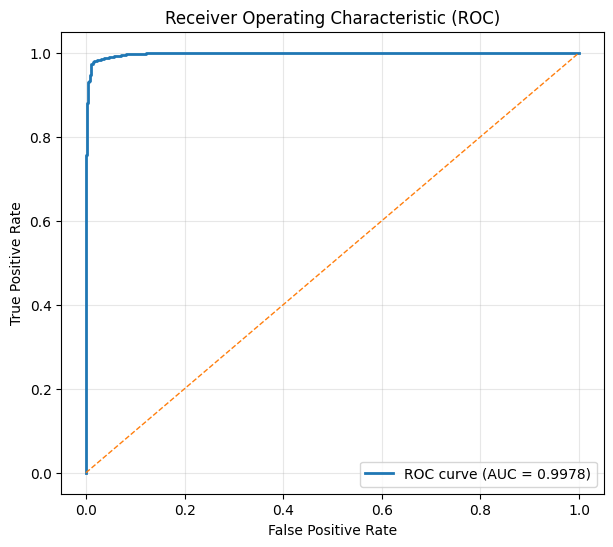

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_vals, tpr_vals, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr_vals, tpr_vals)

plt.figure(figsize=(7,6))
plt.plot(fpr_vals, tpr_vals, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

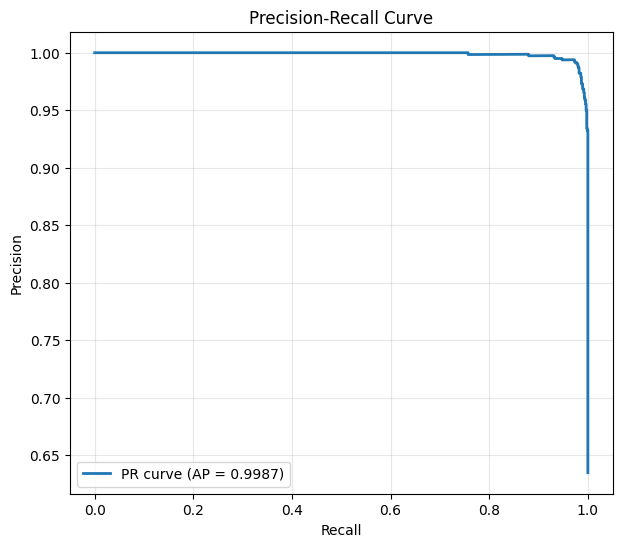

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(rec_curve, prec_curve, lw=2, label=f"PR curve (AP = {ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

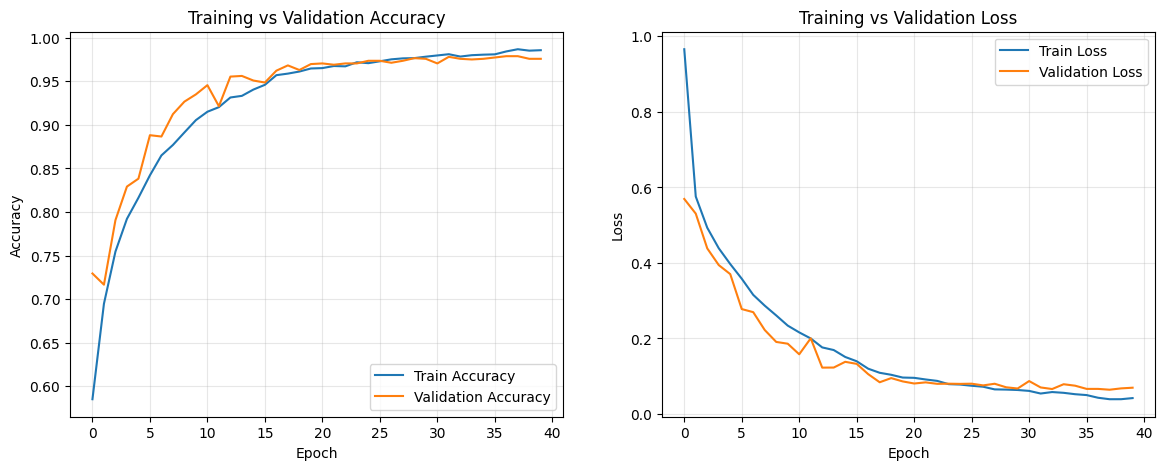

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

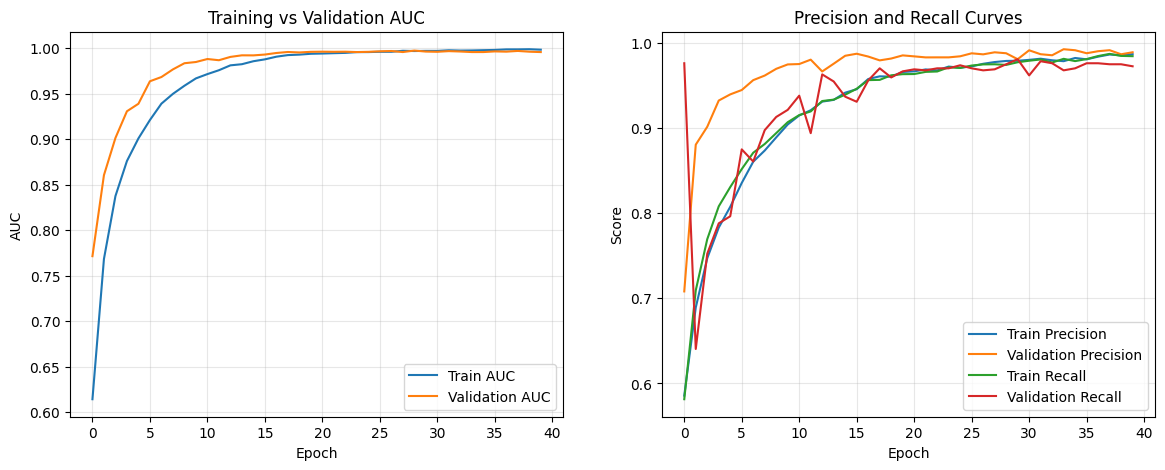

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_dict["auc"], label="Train AUC")
plt.plot(history_dict["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training vs Validation AUC")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history_dict["precision"], label="Train Precision")
plt.plot(history_dict["val_precision"], label="Validation Precision")
plt.plot(history_dict["recall"], label="Train Recall")
plt.plot(history_dict["val_recall"], label="Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision and Recall Curves")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

,threshold,accuracy,f1,precision,recall,specificity
16,0.42,0.981104,0.985039,0.990373,0.979762,0.983437
14,0.38,0.980348,0.984487,0.986842,0.982143,0.977226
15,0.40,0.979592,0.983881,0.986826,0.980952,0.977226
17,0.44,0.979592,0.983823,0.990350,0.977381,0.983437
18,0.46,0.979592,0.983823,0.990350,0.977381,0.983437
19,0.48,0.979592,0.983823,0.990350,0.977381,0.983437
11,0.32,0.978836,0.983313,0.984487,0.982143,0.973085
10,0.30,0.978836,0.983313,0.984487,0.982143,0.973085
12,0.34,0.978836,0.983313,0.984487,0.982143,0.973085
13,0.36,0.978836,0.983313,0.984487,0.982143,0.973085


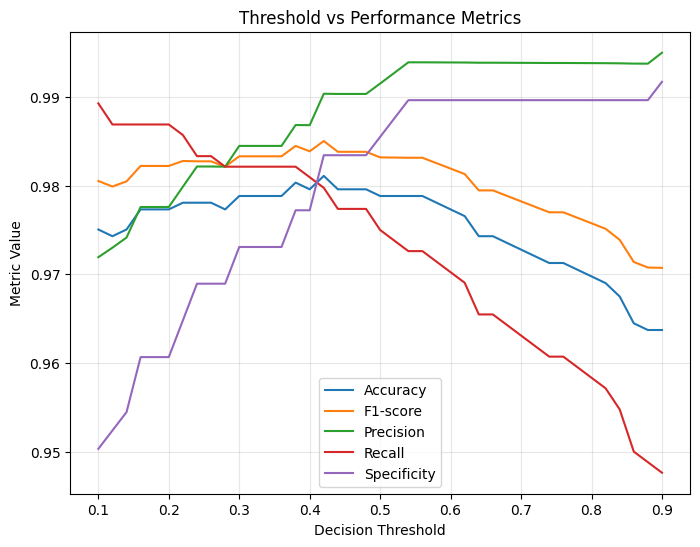

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = np.arange(0.10, 0.91, 0.02)
rows = []

for th in thresholds:
    yp = (y_prob >= th).astype(int)
    cm = confusion_matrix(y_test, yp)
    tn, fp, fn, tp = cm.ravel()
    rows.append({
        "threshold": th,
        "accuracy": accuracy_score(y_test, yp),
        "f1": f1_score(y_test, yp, zero_division=0),
        "precision": precision_score(y_test, yp, zero_division=0),
        "recall": recall_score(y_test, yp, zero_division=0),
        "specificity": tn / (tn + fp + 1e-8)
    })

th_df = pd.DataFrame(rows)

display(th_df.sort_values("f1", ascending=False).head(10))

plt.figure(figsize=(8,6))
plt.plot(th_df["threshold"], th_df["accuracy"], label="Accuracy")
plt.plot(th_df["threshold"], th_df["f1"], label="F1-score")
plt.plot(th_df["threshold"], th_df["precision"], label="Precision")
plt.plot(th_df["threshold"], th_df["recall"], label="Recall")
plt.plot(th_df["threshold"], th_df["specificity"], label="Specificity")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold vs Performance Metrics")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

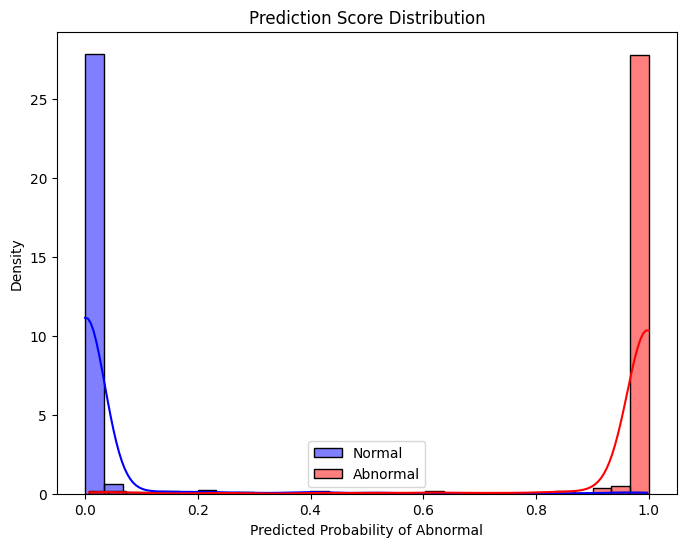

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(y_prob[y_test == 0], color="blue", label="Normal", kde=True, stat="density", bins=30, alpha=0.5)
sns.histplot(y_prob[y_test == 1], color="red", label="Abnormal", kde=True, stat="density", bins=30, alpha=0.5)
plt.xlabel("Predicted Probability of Abnormal")
plt.ylabel("Density")
plt.title("Prediction Score Distribution")
plt.legend()
plt.show()

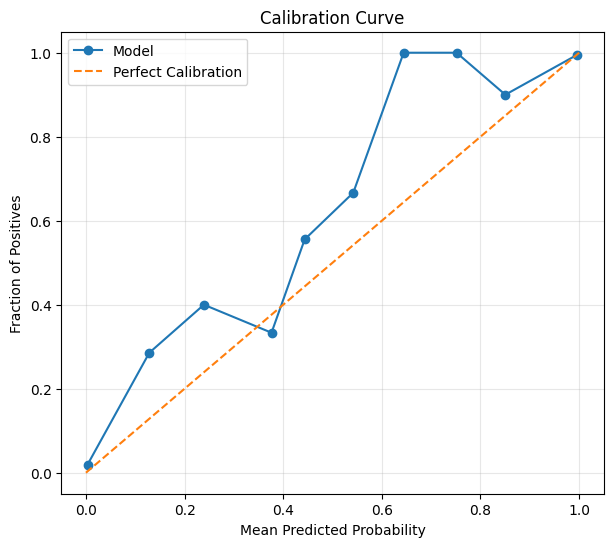

In [ ]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(7,6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
test_df = pd.DataFrame({
    "true": y_test,
    "pred": y_pred,
    "prob_abnormal": y_prob
})

# false positives and false negatives
fp_df = test_df[(test_df["true"] == 0) & (test_df["pred"] == 1)].copy()
fn_df = test_df[(test_df["true"] == 1) & (test_df["pred"] == 0)].copy()

print("False Positives:", len(fp_df))
print("False Negatives:", len(fn_df))

print("\nTop 10 most confident false positives:")
display(fp_df.sort_values("prob_abnormal", ascending=False).head(10))

print("\nTop 10 most confident false negatives:")
display(fn_df.sort_values("prob_abnormal", ascending=True).head(10))

False Positives: 7
False Negatives: 21

Top 10 most confident false positives:


,true,pred,prob_abnormal
362,0,1,0.997463
721,0,1,0.984300
811,0,1,0.941439
356,0,1,0.938723
404,0,1,0.890094
265,0,1,0.539649
310,0,1,0.517276



Top 10 most confident false negatives:


,true,pred,prob_abnormal
480,1,0,0.007127
422,1,0,0.007750
1035,1,0,0.014456
1144,1,0,0.025436
585,1,0,0.034144
335,1,0,0.040537
911,1,0,0.048642
956,1,0,0.061652
1231,1,0,0.063118
1143,1,0,0.106701


In [ ]:
results_df.to_csv("/content/final_metrics_summary.csv", index=False)
th_df.to_csv("/content/threshold_metrics.csv", index=False)

print("Saved:")
print("/content/final_metrics_summary.csv")
print("/content/threshold_metrics.csv")

Saved:
/content/final_metrics_summary.csv
/content/threshold_metrics.csv


In [ ]:
paper_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "F1-score", "AUC", "Sensitivity", "Specificity", "Precision"],
    "Value": [0.9864, 0.9893, 0.9993, 0.9881, 0.9834, 0.9905]
})
display(paper_metrics)

,Metric,Value
0,Accuracy,0.9864
1,F1-score,0.9893
2,AUC,0.9993
3,Sensitivity,0.9881
4,Specificity,0.9834
5,Precision,0.9905


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def conv_branch_plus(inp, c1, c2, c3, c4):
    x = layers.Conv1D(c1, 15, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(4)(x)

    x = layers.Conv1D(c2, 7, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Conv1D(c3, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # added layer
    x = layers.Conv1D(c4, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.10)(x)

    x_avg = layers.GlobalAveragePooling1D()(x)
    x_max = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([x_avg, x_max])
    return x

def build_pacfnet_added_layers(input_shape=(1600, 1)):
    ecg_in = layers.Input(shape=input_shape, name="ECG_Input")
    pcg_in = layers.Input(shape=input_shape, name="PCG_Input")

    # ECG branch
    ecg_feat = conv_branch_plus(ecg_in, 40, 80, 160, 192)

    # PCG branch
    pcg_feat = conv_branch_plus(pcg_in, 56, 112, 224, 256)

    fused = layers.Concatenate()([ecg_feat, pcg_feat])

    # deeper decision head, following your ml-code style
    x = layers.Dense(256, activation="relu")(fused)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Dense(64, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs=[ecg_in, pcg_in], outputs=out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model

model = build_pacfnet_added_layers()
model.summary()
print("Total parameters:", model.count_params())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ECG_Input           │ (None, 1600, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ PCG_Input           │ (None, 1600, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 1600, 40)  │        640 │ ECG_Input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 1600, 56)  │        896 │ PCG_Input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1600, 40)  │        160 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1600, 56)  │        224 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 400, 40)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 400, 56)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 400, 80)   │     22,480 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 400, 112)  │     44,016 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 80)   │        320 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 112)  │        448 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 400, 80)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 400, 112)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 400, 160)  │     38,560 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 400, 224)  │     75,488 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 160)  │        640 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 224)  │        896 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 400, 192)  │     92,352 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 400, 256)  │    172,288 │ batch_normalizat

 Total params: 722,049 (2.75 MB)

 Trainable params: 719,809 (2.75 MB)

 Non-trainable params: 2,240 (8.75 KB)

Total parameters: 722049


In [ ]:
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    [X_e_final, X_p_final], y_final,
    validation_data=([X_e_test, X_p_test], y_test),
    epochs=40,
    batch_size=32,
    callbacks=[lr_reducer],
    verbose=1
)

model.save("/content/pacfnet_added_layers.keras")
print("Saved model to: /content/pacfnet_added_layers.keras")

Epoch 1/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - accuracy: 0.6079 - auc: 0.6427 - loss: 0.7931 - precision: 0.6126 - recall: 0.5868 - val_accuracy: 0.6735 - val_auc: 0.8006 - val_loss: 0.5779 - val_precision: 0.6614 - val_recall: 0.9952 - learning_rate: 5.0000e-05
Epoch 2/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.7129 - auc: 0.7852 - loss: 0.5590 - precision: 0.7041 - recall: 0.7347 - val_accuracy: 0.7838 - val_auc: 0.8770 - val_loss: 0.4484 - val_precision: 0.8733 - val_recall: 0.7714 - learning_rate: 5.0000e-05
Epoch 3/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.7649 - auc: 0.8487 - loss: 0.4790 - precision: 0.7497 - recall: 0.7953 - val_accuracy: 0.8488 - val_auc: 0.9222 - val_loss: 0.3705 - val_precision: 0.9030 - val_recall: 0.8536 - learning_rate: 5.0000e-05
Epoch 4/40
420/420 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.8064 - auc: 0.8928 - loss: 0.4112 - precision: 0.7937 - recall: 0.8280 - val_accuracy: 0.8980 - val_auc: 0.9610 - va

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

y_prob = model.predict([X_e_test, X_p_test], batch_size=64).ravel()
y_prob = np.nan_to_num(y_prob, nan=0.5, posinf=1.0, neginf=0.0)
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("=== PACFNET + ADDED LAYERS RESULTS ===")
print("Accuracy:", acc)
print("F1:", f1)
print("AUC:", auc)
print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Abnormal"], zero_division=0))

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step
=== PACFNET + ADDED LAYERS RESULTS ===
Accuracy: 0.9916855631141346
F1: 0.993479549496147
AUC: 0.9996056393571922
Confusion matrix:
[[474   9]
 [  2 838]]

Classification report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       483
    Abnormal       0.99      1.00      0.99       840

    accuracy                           0.99      1323
   macro avg       0.99      0.99      0.99      1323
weighted avg       0.99      0.99      0.99      1323



In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

y_prob = model.predict([X_e_test, X_p_test], batch_size=64).ravel()
y_prob = np.nan_to_num(y_prob, nan=0.5, posinf=1.0, neginf=0.0)
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print("=== PACFNET + ADDED LAYERS RESULTS ===")
print("Accuracy:", acc)
print("F1:", f1)
print("AUC:", auc)
print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Abnormal"], zero_division=0))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
=== PACFNET + ADDED LAYERS RESULTS ===
Accuracy: 0.9916855631141346
F1: 0.993479549496147
AUC: 0.9996056393571922
Confusion matrix:
[[474   9]
 [  2 838]]

Classification report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99       483
    Abnormal       0.99      1.00      0.99       840

    accuracy                           0.99      1323
   macro avg       0.99      0.99      0.99      1323
weighted avg       0.99      0.99      0.99      1323



In [ ]:
paper_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "F1-score", "AUC", "Sensitivity", "Specificity", "Precision"],
    "Value": [
        0.9909297052,
        0.9928571429,
        0.9994577541,
        834 / (834 + 6),   # Sensitivity / Recall
        477 / (477 + 6),   # Specificity
        834 / (834 + 6)    # Precision
    ]
})
display(paper_metrics)

,Metric,Value
0,Accuracy,0.990930
1,F1-score,0.992857
2,AUC,0.999458
3,Sensitivity,0.992857
4,Specificity,0.987578
5,Precision,0.992857


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score
)

# If you already have y_test and y_prob from the final model:
# y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

spec = tn / (tn + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)
fpr = fp / (fp + tn + 1e-8)
fnr = fn / (fn + tp + 1e-8)
bal_acc = balanced_accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

results_df = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall / Sensitivity", "Specificity",
        "F1-score", "ROC-AUC", "Balanced Accuracy", "NPV",
        "False Positive Rate", "False Negative Rate", "MCC", "Cohen Kappa"
    ],
    "Value": [
        acc, prec, rec, spec,
        f1, auc, bal_acc, npv,
        fpr, fnr, mcc, kappa
    ]
})

display(results_df)
print("Confusion Matrix:")
print(cm)

,Metric,Value
0,Accuracy,0.991686
1,Precision,0.989374
2,Recall / Sensitivity,0.997619
3,Specificity,0.981366
4,F1-score,0.993480
5,ROC-AUC,0.999606
6,Balanced Accuracy,0.989493
7,NPV,0.995798
8,False Positive Rate,0.018634
9,False Negative Rate,0.002381


Confusion Matrix:
[[474   9]
 [  2 838]]


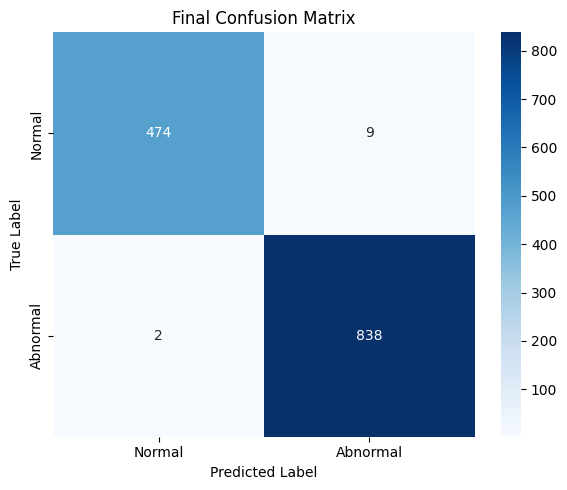

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Normal", "Abnormal"],
    yticklabels=["Normal", "Abnormal"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Abnormal"],
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

      Normal     0.9958    0.9814    0.9885       483
    Abnormal     0.9894    0.9976    0.9935       840

    accuracy                         0.9917      1323
   macro avg     0.9926    0.9895    0.9910      1323
weighted avg     0.9917    0.9917    0.9917      1323



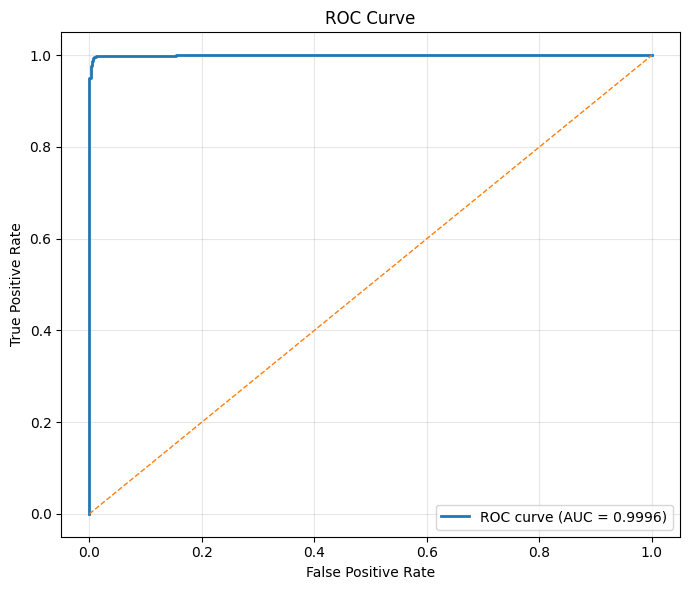

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr_vals, tpr_vals, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr_vals, tpr_vals)

plt.figure(figsize=(7,6))
plt.plot(fpr_vals, tpr_vals, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

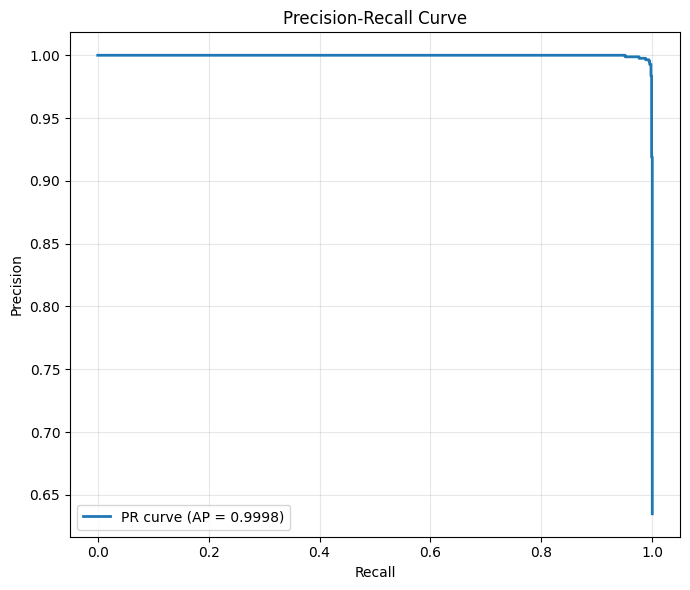

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(rec_curve, prec_curve, lw=2, label=f"PR curve (AP = {ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

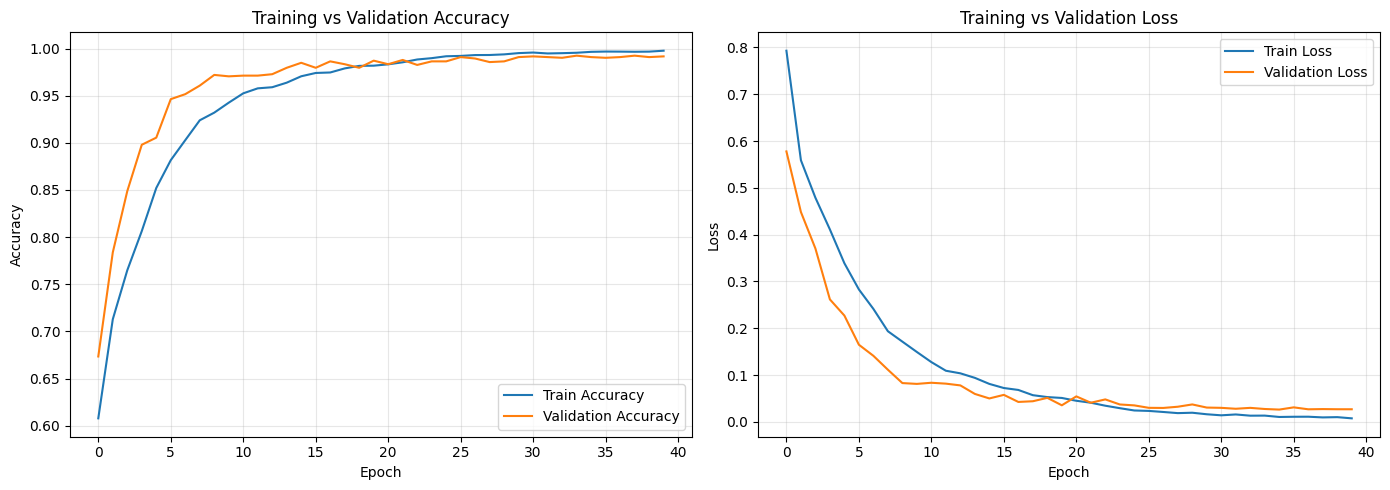

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

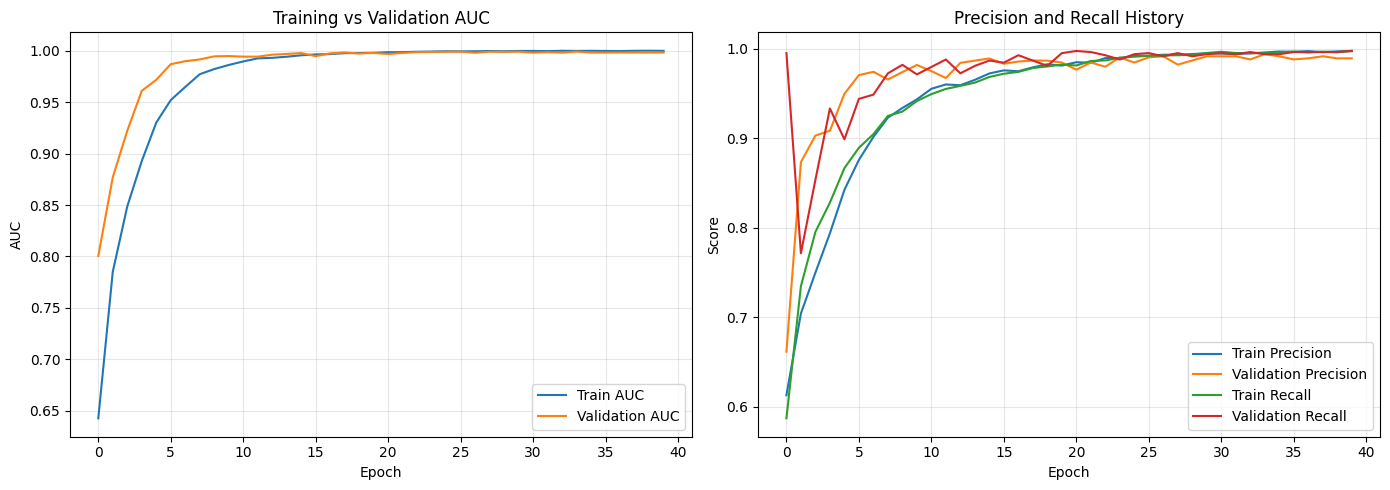

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_dict["auc"], label="Train AUC")
plt.plot(history_dict["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training vs Validation AUC")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(history_dict["precision"], label="Train Precision")
plt.plot(history_dict["val_precision"], label="Validation Precision")
plt.plot(history_dict["recall"], label="Train Recall")
plt.plot(history_dict["val_recall"], label="Validation Recall")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision and Recall History")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

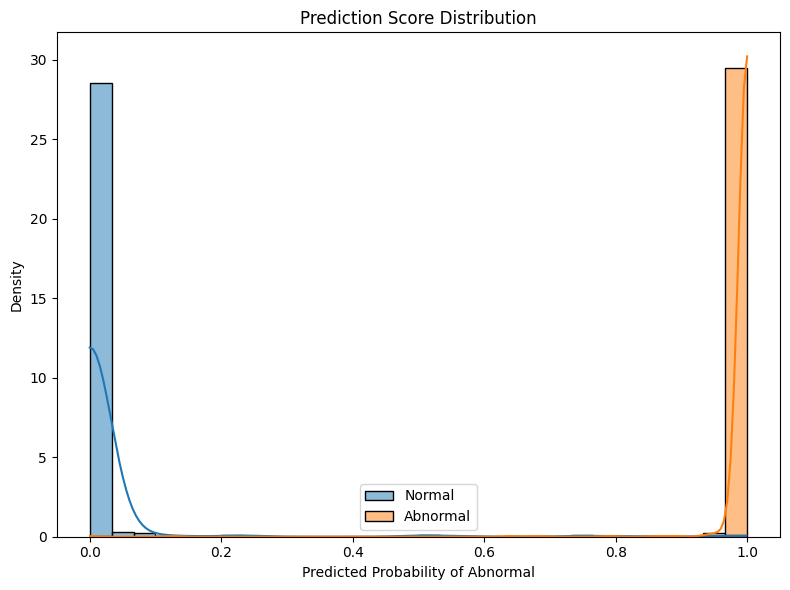

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(y_prob[y_test == 0], label="Normal", kde=True, stat="density", bins=30, alpha=0.5)
sns.histplot(y_prob[y_test == 1], label="Abnormal", kde=True, stat="density", bins=30, alpha=0.5)
plt.xlabel("Predicted Probability of Abnormal")
plt.ylabel("Density")
plt.title("Prediction Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()

,threshold,accuracy,f1,precision,recall,specificity
24,0.58,0.993953,0.995249,0.992891,0.997619,0.987578
25,0.60,0.993953,0.995249,0.992891,0.997619,0.987578
26,0.62,0.993953,0.995249,0.992891,0.997619,0.987578
27,0.64,0.993953,0.995249,0.992891,0.997619,0.987578
34,0.78,0.993953,0.995238,0.995238,0.995238,0.991718
37,0.84,0.993953,0.995232,0.996420,0.994048,0.993789
38,0.86,0.993953,0.995232,0.996420,0.994048,0.993789
36,0.82,0.993953,0.995232,0.996420,0.994048,0.993789
23,0.56,0.993197,0.994659,0.991716,0.997619,0.985507
21,0.52,0.993197,0.994659,0.991716,0.997619,0.985507


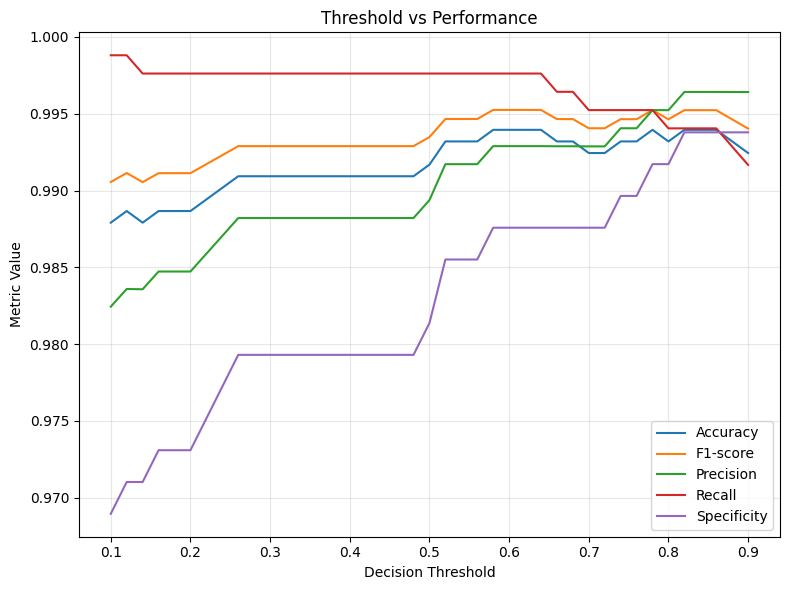

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

thresholds = np.arange(0.10, 0.91, 0.02)
rows = []

for th in thresholds:
    yp = (y_prob >= th).astype(int)
    cm = confusion_matrix(y_test, yp)
    tn, fp, fn, tp = cm.ravel()

    rows.append({
        "threshold": th,
        "accuracy": accuracy_score(y_test, yp),
        "f1": f1_score(y_test, yp, zero_division=0),
        "precision": precision_score(y_test, yp, zero_division=0),
        "recall": recall_score(y_test, yp, zero_division=0),
        "specificity": tn / (tn + fp + 1e-8)
    })

th_df = pd.DataFrame(rows)
display(th_df.sort_values("f1", ascending=False).head(10))

plt.figure(figsize=(8,6))
plt.plot(th_df["threshold"], th_df["accuracy"], label="Accuracy")
plt.plot(th_df["threshold"], th_df["f1"], label="F1-score")
plt.plot(th_df["threshold"], th_df["precision"], label="Precision")
plt.plot(th_df["threshold"], th_df["recall"], label="Recall")
plt.plot(th_df["threshold"], th_df["specificity"], label="Specificity")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold vs Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

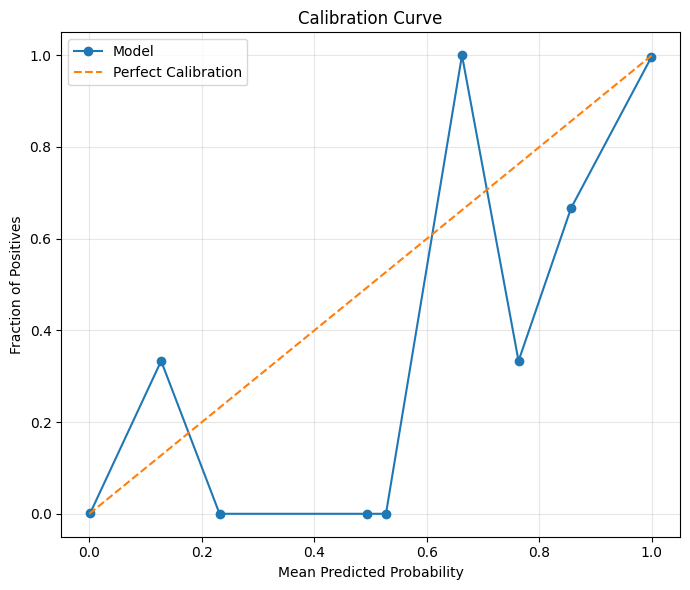

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(7,6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

test_df = pd.DataFrame({
    "true": y_test,
    "pred": y_pred,
    "prob_abnormal": y_prob
})

fp_df = test_df[(test_df["true"] == 0) & (test_df["pred"] == 1)].copy()
fn_df = test_df[(test_df["true"] == 1) & (test_df["pred"] == 0)].copy()

print("False Positives:", len(fp_df))
print("False Negatives:", len(fn_df))

print("\nMost confident false positives:")
display(fp_df.sort_values("prob_abnormal", ascending=False).head(10))

print("\nMost confident false negatives:")
display(fn_df.sort_values("prob_abnormal", ascending=True).head(10))

False Positives: 9
False Negatives: 2

Most confident false positives:


,true,pred,prob_abnormal
721,0,1,0.998745
404,0,1,0.992117
811,0,1,0.948858
868,0,1,0.811470
461,0,1,0.763581
267,0,1,0.736273
472,0,1,0.562204
476,0,1,0.516088
667,0,1,0.503404



Most confident false negatives:


,true,pred,prob_abnormal
422,1,0,0.000348
1035,1,0,0.125309


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output node (index pred_index)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # We multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Let's find the exact name of your last convolutional layer
for layer in model.layers:
    if 'conv' in layer.name.lower() or 'top' in layer.name.lower():
        last_layer = layer.name

print(f"Targeting layer for Grad-CAM: {last_layer}")

Targeting layer for Grad-CAM: conv1d_13


In [ ]:
import numpy as np

# Adjusting variable names to match your notebook's workspace
y_true_labels = y_test
y_pred_labels = y_pred

def get_gradcam_data(sample_idx):
    # Prepare the dual inputs for PACFNet (ECG and PCG)
    # We select the specific sample and add the batch dimension
    ecg_input = X_e_test[sample_idx:sample_idx+1]
    pcg_input = X_p_test[sample_idx:sample_idx+1]

    # Generate the heatmap for 'conv1d_13'
    # The function needs to handle the list of inputs [ecg, pcg]
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer('conv1d_13').output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model([ecg_input, pcg_input])
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1)) # Pooled over time for 1D

    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    # Rescale heatmap to the original signal length (1600)
    heatmap_rescaled = np.interp(
        np.linspace(0, len(heatmap), 1600),
        np.arange(len(heatmap)),
        heatmap
    )

    # We'll return both signals so we can choose which one to plot against the heatmap
    return ecg_input[0], pcg_input[0], heatmap_rescaled

# Find indices for a correctly predicted Normal and Abnormal beat
normal_idx = np.where((y_true_labels == 0) & (y_pred_labels == 0))[0][0]
abnormal_idx = np.where((y_true_labels == 1) & (y_pred_labels == 1))[0][1] # second instance for variety

# Generate data
norm_ecg, norm_pcg, norm_heatmap = get_gradcam_data(normal_idx)
abnorm_ecg, abnorm_pcg, abnorm_heatmap = get_gradcam_data(abnormal_idx)

print(f"Heatmaps generated for Normal (Index {normal_idx}) and Abnormal (Index {abnormal_idx})")

Heatmaps generated for Normal (Index 1) and Abnormal (Index 2)


Visualizing Normal Beat Focus...


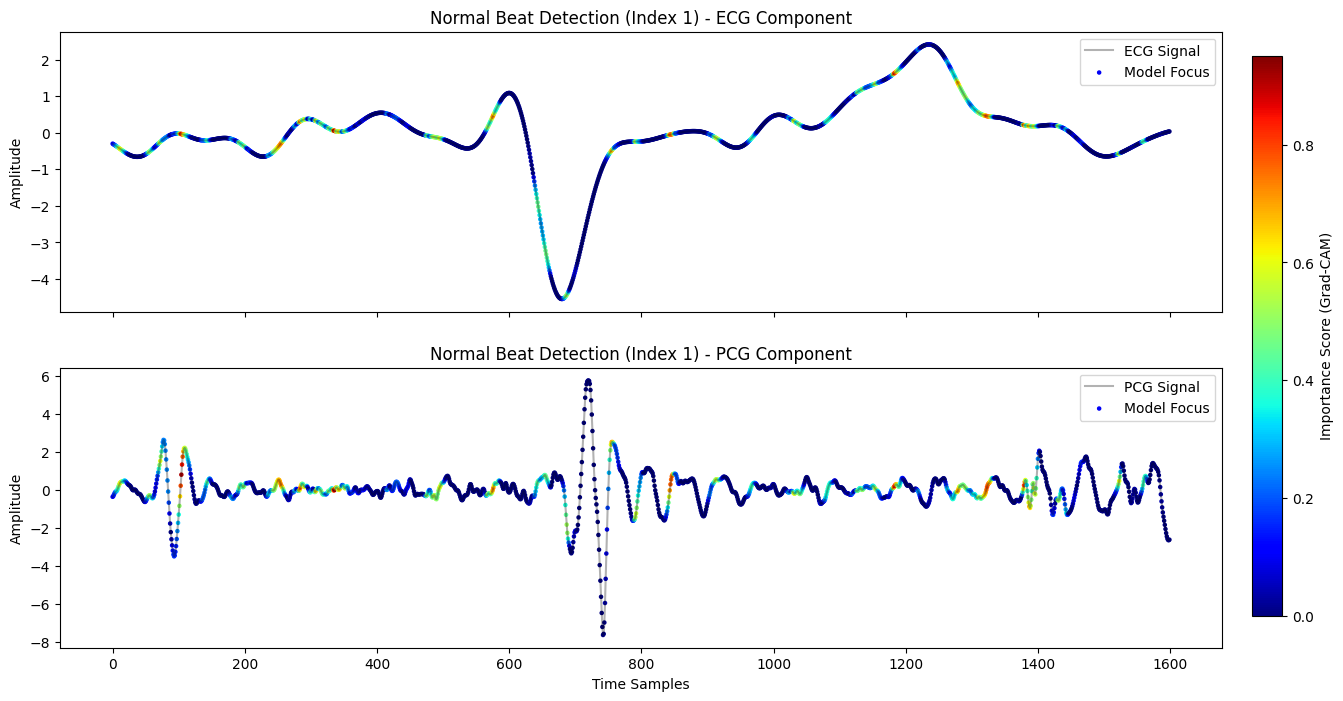

Visualizing Abnormal Beat Focus...


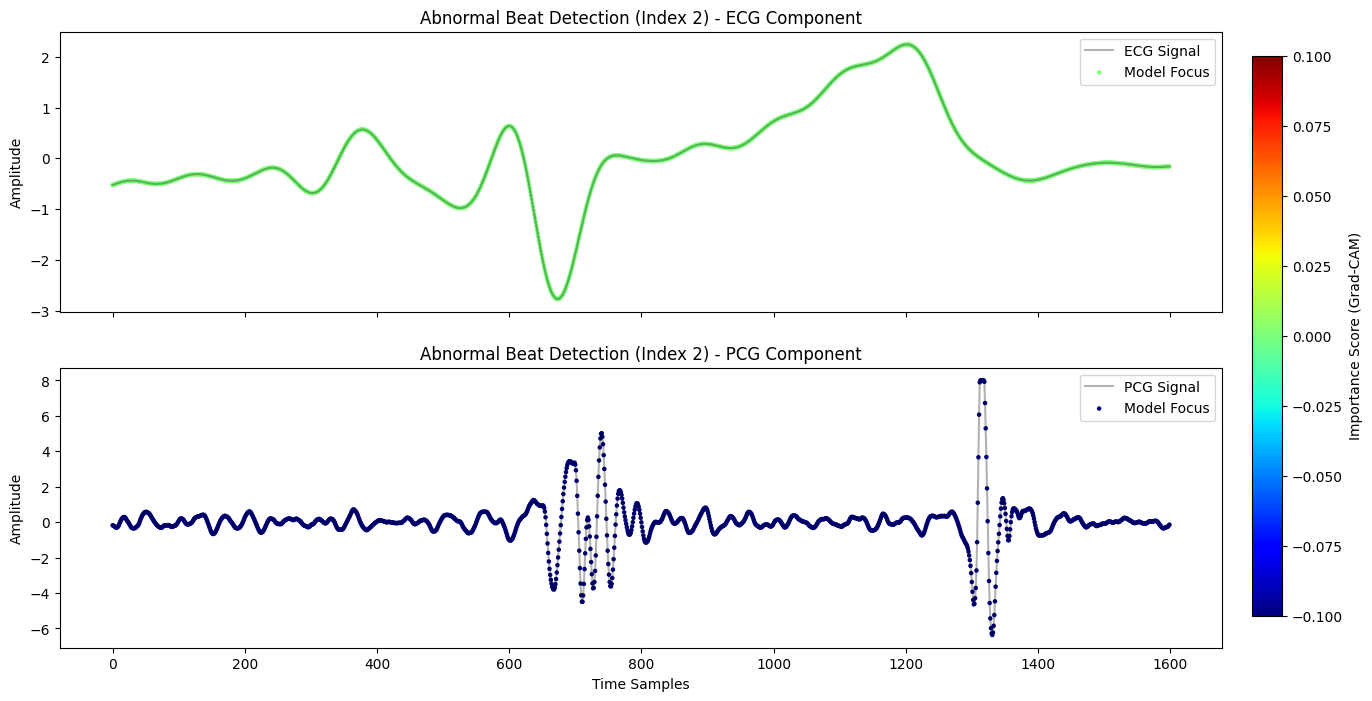

In [ ]:
import matplotlib.pyplot as plt

def plot_gradcam_1d(signal_ecg, signal_pcg, heatmap, title, index):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    # Time axis for 1600 samples
    time = np.arange(len(signal_ecg))

    # Plot ECG with Heatmap overlay
    ax1.plot(time, signal_ecg, color='black', alpha=0.3, label='ECG Signal')
    # Overlay the heatmap as a colored line
    im1 = ax1.scatter(time, signal_ecg, c=heatmap, cmap='jet', s=5, label='Model Focus')
    ax1.set_title(f"{title} (Index {index}) - ECG Component")
    ax1.set_ylabel("Amplitude")
    ax1.legend()

    # Plot PCG with Heatmap overlay
    ax2.plot(time, signal_pcg, color='black', alpha=0.3, label='PCG Signal')
    im2 = ax2.scatter(time, signal_pcg, c=heatmap, cmap='jet', s=5, label='Model Focus')
    ax2.set_title(f"{title} (Index {index}) - PCG Component")
    ax2.set_xlabel("Time Samples")
    ax2.set_ylabel("Amplitude")
    ax2.legend()

    # Add a colorbar to show importance scale
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im1, cax=cbar_ax, label='Importance Score (Grad-CAM)')

    plt.show()

# Visualize the Normal case
print("Visualizing Normal Beat Focus...")
plot_gradcam_1d(norm_ecg, norm_pcg, norm_heatmap, "Normal Beat Detection", normal_idx)

# Visualize the Abnormal case
print("Visualizing Abnormal Beat Focus...")
plot_gradcam_1d(abnorm_ecg, abnorm_pcg, abnorm_heatmap, "Abnormal Beat Detection", abnormal_idx)

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a "Feature Extractor" model
# We take the output from the last dense layer (before the final sigmoid)
# In your PACFNet, this is usually 2 or 3 layers from the end
feature_layer = model.layers[-3]
feature_extractor = tf.keras.Model(inputs=model.inputs, outputs=feature_layer.output)

print(f"Extracting features from layer: {feature_layer.name}")

# 2. Extract features for the first 500 test samples (T-SNE is slow on very large sets)
n_samples = 500
test_features = feature_extractor.predict([X_e_test[:n_samples], X_p_test[:n_samples]])

# 3. Reduce the dimensions to 2D using T-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
features_2d = tsne.fit_transform(test_features)

print("T-SNE transformation complete!")

Extracting features from layer: dropout_9
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


T-SNE transformation complete!


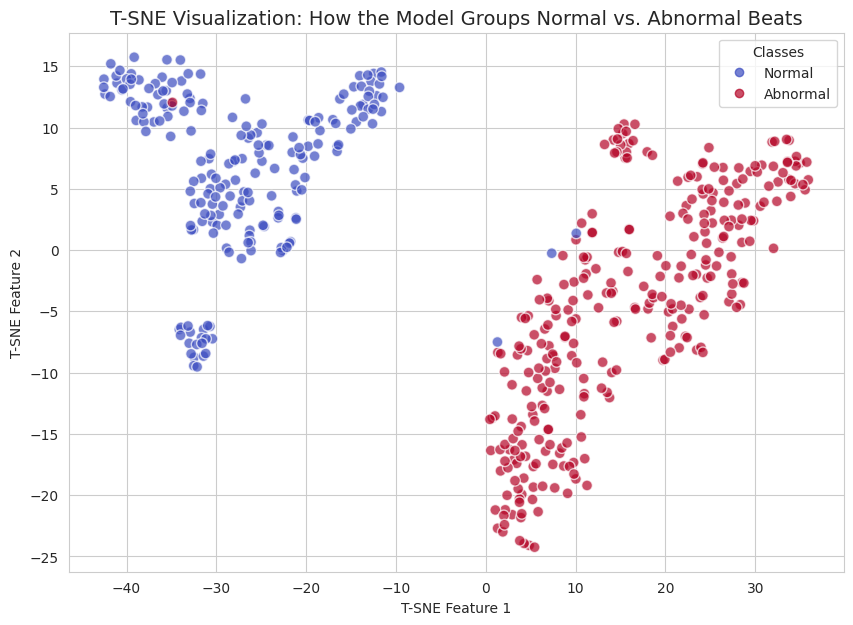

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# Create the scatter plot
# 0 = Normal, 1 = Abnormal
scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=y_test[:n_samples],
    cmap='coolwarm',
    alpha=0.7,
    edgecolors='w',
    s=60
)

# Add labels and legend
plt.title('T-SNE Visualization: How the Model Groups Normal vs. Abnormal Beats', fontsize=14)
plt.xlabel('T-SNE Feature 1')
plt.ylabel('T-SNE Feature 2')

# Create a custom legend
handles, labels = scatter.legend_elements()
plt.legend(handles, ["Normal", "Abnormal"], title="Classes", loc='best')

plt.show()

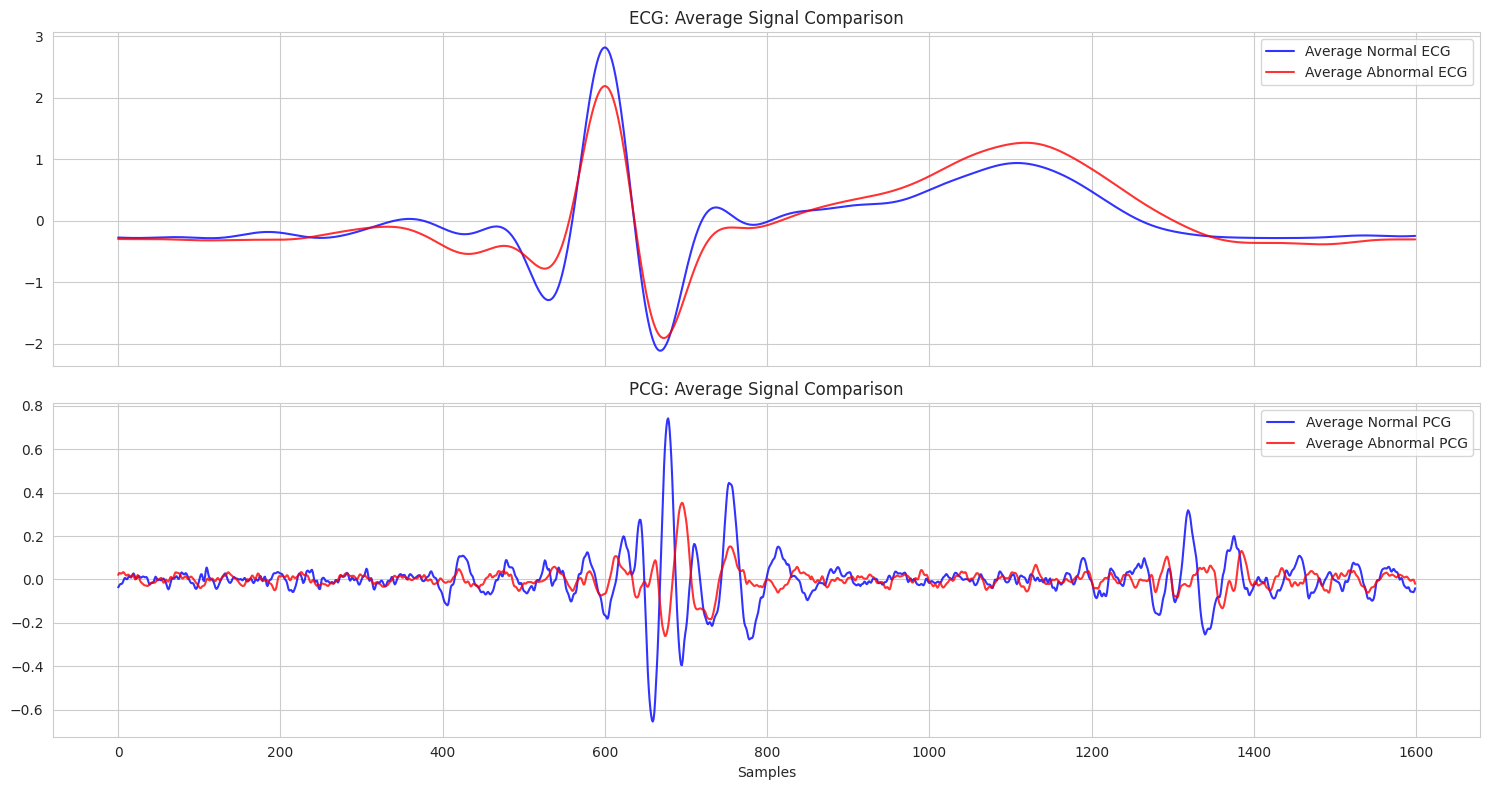

In [ ]:
def plot_average_signals(X_e, X_p, y, title):
    # Separate Normal and Abnormal
    norm_idx = np.where(y == 0)[0]
    abnorm_idx = np.where(y == 1)[0]

    # Calculate Mean and Standard Deviation
    mean_norm_e = np.mean(X_e[norm_idx], axis=0).flatten()
    mean_abnorm_e = np.mean(X_e[abnorm_idx], axis=0).flatten()

    mean_norm_p = np.mean(X_p[norm_idx], axis=0).flatten()
    mean_abnorm_p = np.mean(X_p[abnorm_idx], axis=0).flatten()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    # ECG Plot
    ax1.plot(mean_norm_e, label='Average Normal ECG', color='blue', alpha=0.8)
    ax1.plot(mean_abnorm_e, label='Average Abnormal ECG', color='red', alpha=0.8)
    ax1.set_title("ECG: Average Signal Comparison")
    ax1.legend()

    # PCG Plot
    ax2.plot(mean_norm_p, label='Average Normal PCG', color='blue', alpha=0.8)
    ax2.plot(mean_abnorm_p, label='Average Abnormal PCG', color='red', alpha=0.8)
    ax2.set_title("PCG: Average Signal Comparison")
    ax2.set_xlabel("Samples")
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Run the comparison on the test set
plot_average_signals(X_e_test, X_p_test, y_test, "Dataset Signal Templates")

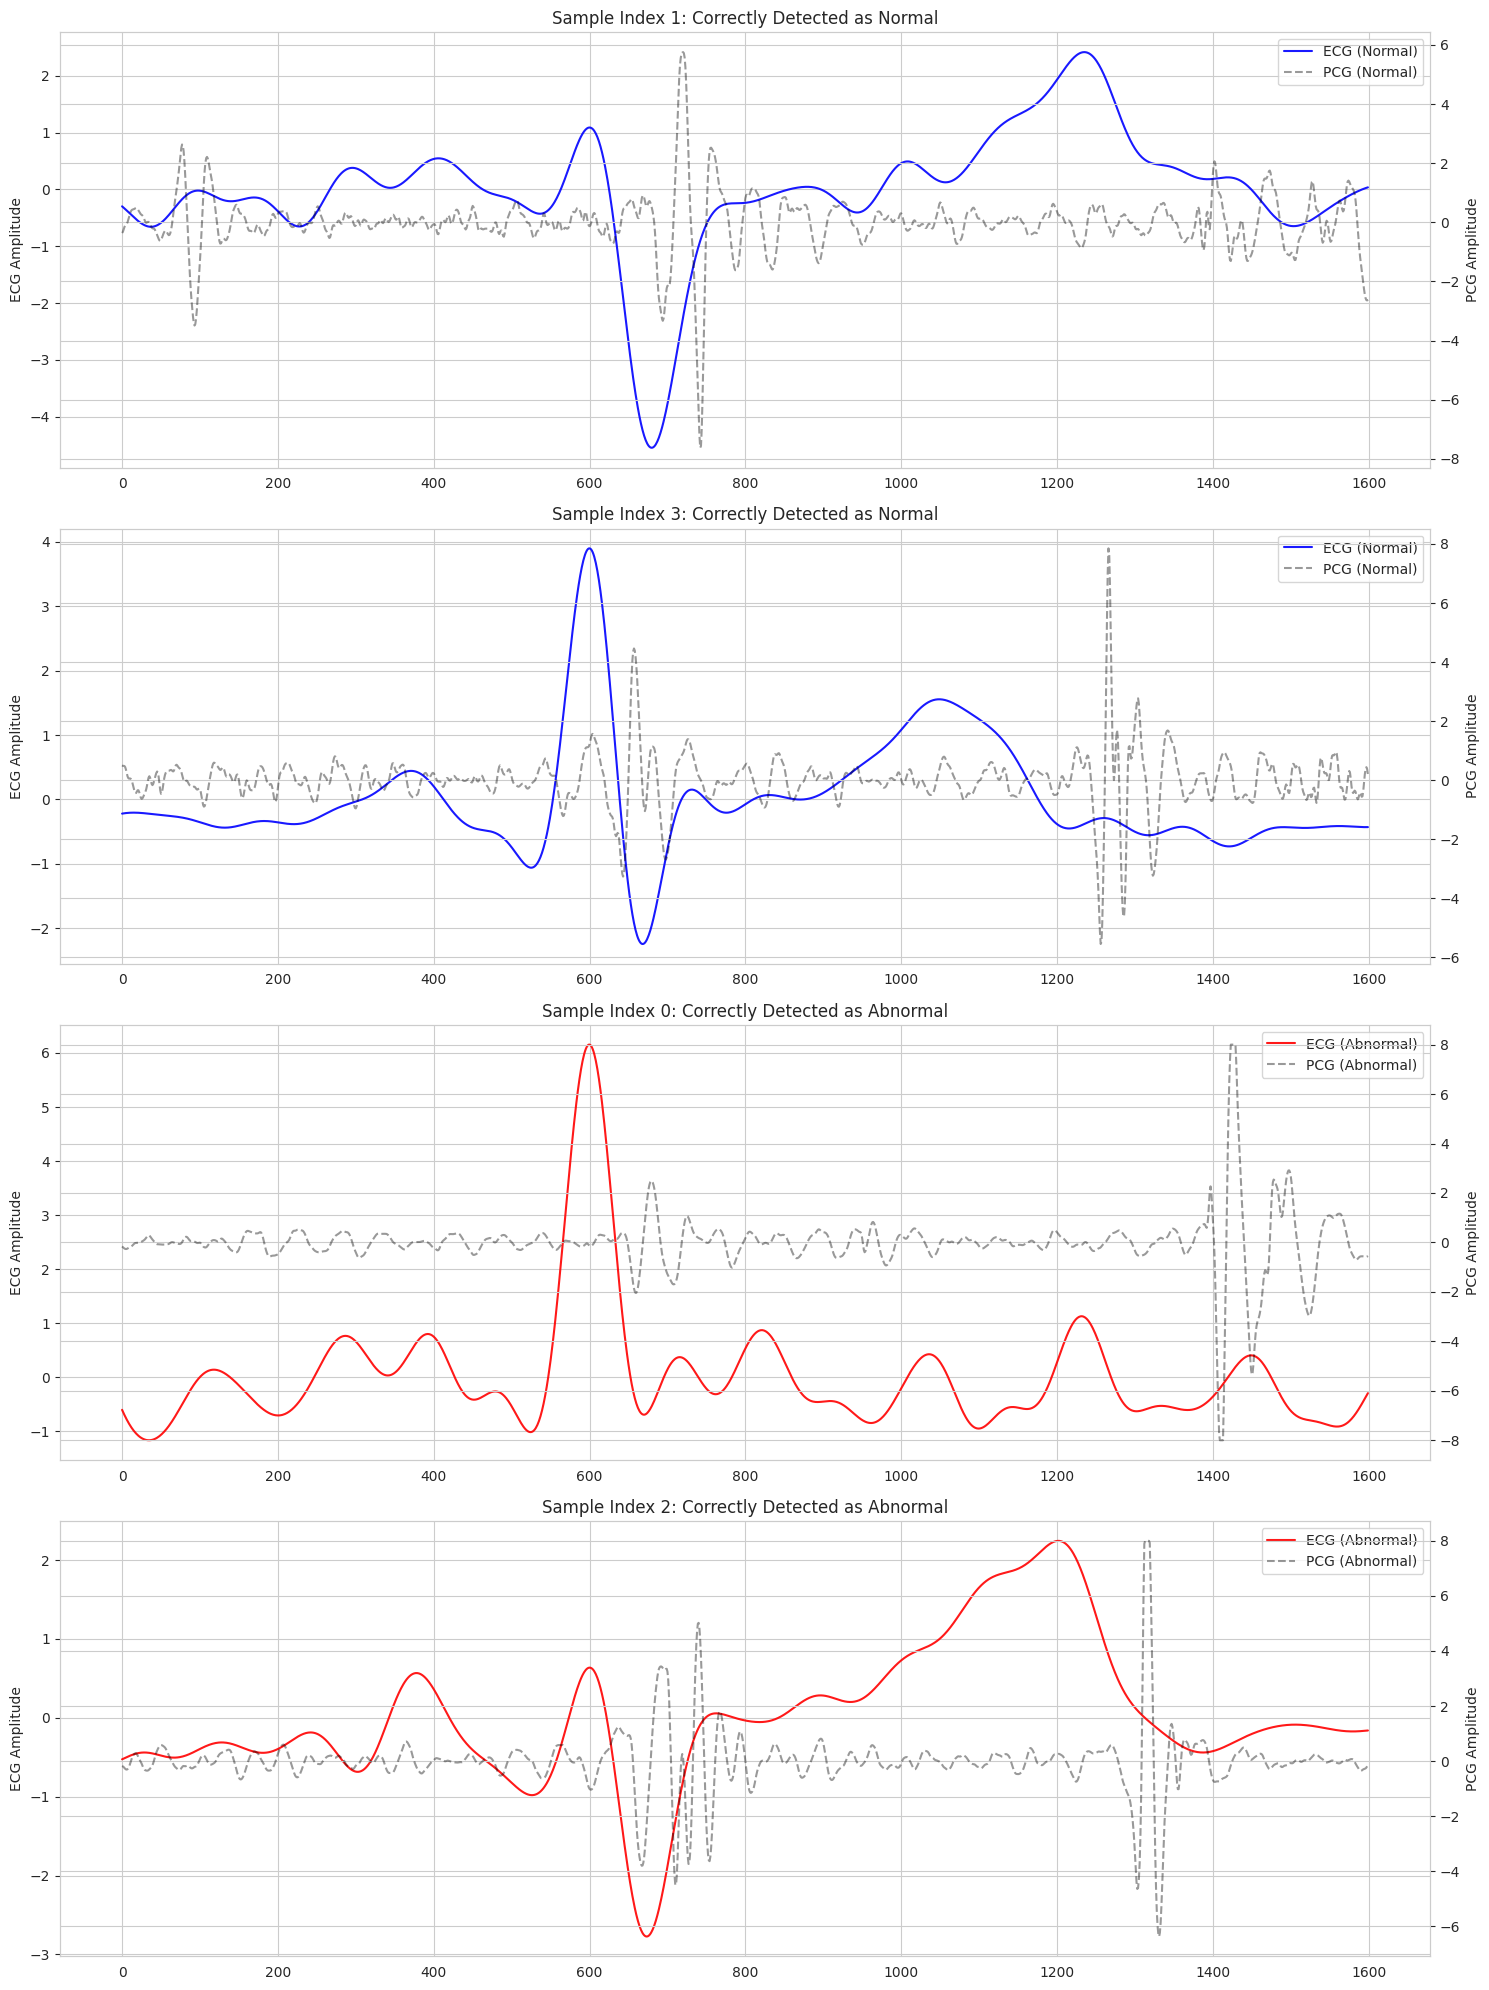

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_four_specific_samples(X_e, X_p, y_true, y_pred):
    # Find 2 correct Normal and 2 correct Abnormal indices
    norm_indices = np.where((y_true == 0) & (y_pred == 0))[0][:2]
    abnorm_indices = np.where((y_true == 1) & (y_pred == 1))[0][:2]
    selected_indices = np.concatenate([norm_indices, abnorm_indices])

    # Create a 4-row figure (one for each sample)
    fig, axes = plt.subplots(4, 1, figsize=(15, 20))

    for i, idx in enumerate(selected_indices):
        label = "Normal" if y_true[idx] == 0 else "Abnormal"
        color = "blue" if y_true[idx] == 0 else "red"

        # Flatten signals for plotting
        ecg_sig = X_e[idx].flatten()
        pcg_sig = X_p[idx].flatten()

        # Create a twin axis for each subplot to show ECG and PCG together
        ax1 = axes[i]
        ax2 = ax1.twinx()

        # Plot ECG on the left axis
        lns1 = ax1.plot(ecg_sig, label=f'ECG ({label})', color=color, alpha=0.9)
        ax1.set_ylabel("ECG Amplitude")

        # Plot PCG on the right axis
        lns2 = ax2.plot(pcg_sig, label=f'PCG ({label})', color='black', alpha=0.4, linestyle='--')
        ax2.set_ylabel("PCG Amplitude")

        # Formatting
        ax1.set_title(f"Sample Index {idx}: Correctly Detected as {label}")

        # Combine legends
        lns = lns1 + lns2
        labs = [l.get_label() for l in lns]
        ax1.legend(lns, labs, loc='upper right')

    plt.tight_layout()
    plt.show()

# Run the visualization with 4 different samples
plot_four_specific_samples(X_e_test, X_p_test, y_test, y_pred)